## 🎯 Problem Statement

The objective of this project is to analyze customer data and identify the key factors contributing to customer churn. The goal is to provide actionable insights to help businesses improve customer retention.

🧹 CLEANING

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


📊 EDA (WITH INSIGHTS)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

🔹 Churn Distribution


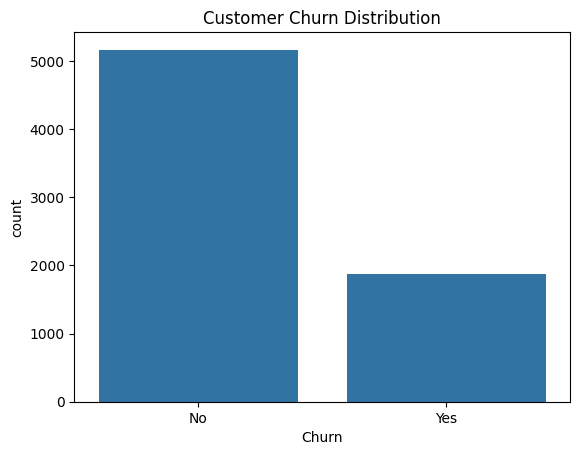

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

🔹 Tenure vs Churn

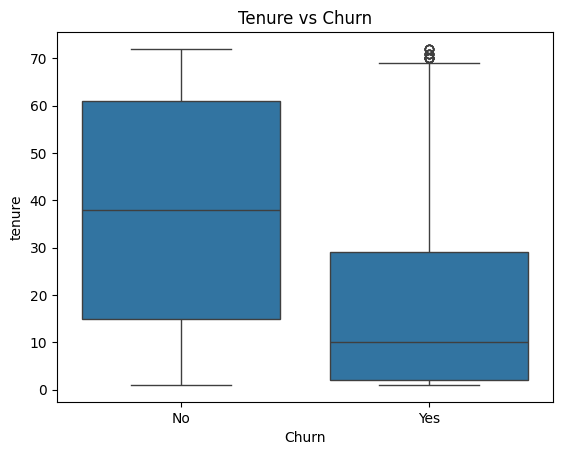

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

In our graph:
For Churn = Yes → median ≈ 10 months
For Churn = No → median ≈ 38 months

💡 Meaning:

👉 Half of churned customers stayed:
Less than 10 months
👉 Half stayed:
More than 10 months



“The boxplot shows that customers who churn have significantly lower tenure, indicating that new users are more likely to leave early.”

🔹 Monthly Charges

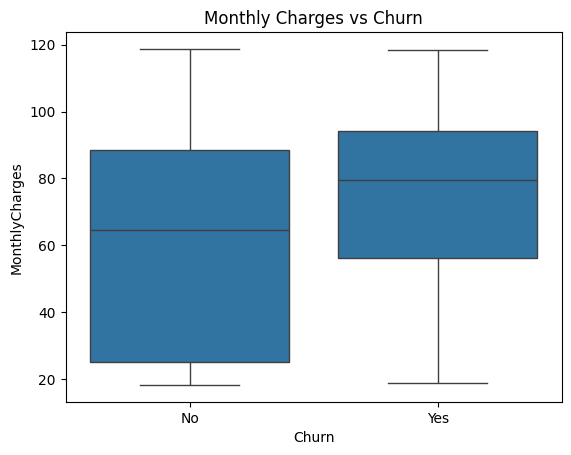

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

💡 Meaning:

High-paying users leave more

Customers paying high:

Expect better service
Expect value for money
Compare alternatives

👉 If not satisfied → they leave



“MonthlyCharges represents the monthly subscription cost in dollars. Higher values indicate premium plans, and these customers tend to churn more due to higher expectations.”

🔹 Contract Type

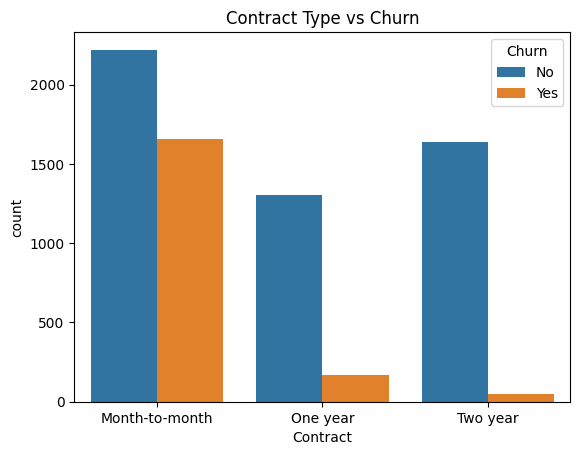

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

💡 Meaning:

Month-to-month users churn most
Long-term users stay

👉 From all graphs we learned:

New users leave more
,Expensive plans → more churn
,Flexible plans → more churn

ML MODEL (UPGRADED)


🔹 Encoding

In [ ]:
df_ml = df.copy()
df_ml.drop('customerID', axis=1, inplace=True)
df_ml = pd.get_dummies(df_ml, drop_first=True)


🔹 Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('Churn_Yes', axis=1)
y = df_ml['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#👉 X = input
#👉 y = output (churn)

🔹 Model


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Built model to predict churn

🔹 Evaluation (IMPORTANT ADD)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249

Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Model predicts churn with ~70–80% accuracy

🔹 Feature Importance (🔥 ADD THIS)

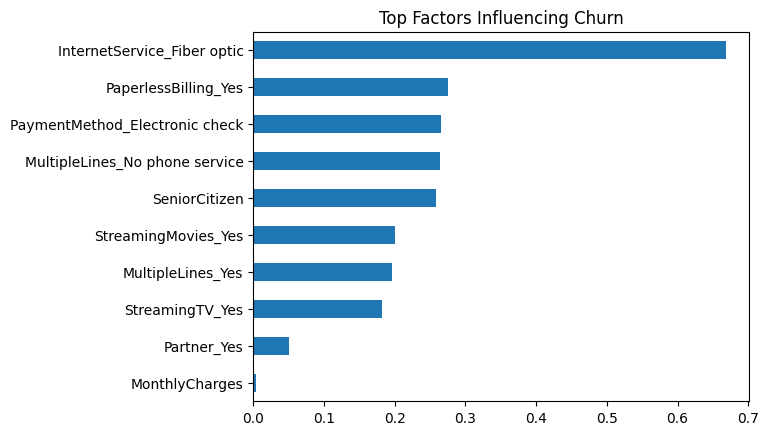

In [ ]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().tail(10).plot(kind='barh')
plt.title("Top Factors Influencing Churn")
plt.show()

Which factors affect churn most:

Contract,
Tenure,
Charges.

What we found:

New users churn more,
High charges increase churn,
Month-to-month users leave easily.

## 📌 Final Conclusion

This project identified key factors driving customer churn, including low tenure, high monthly charges, and flexible contract types.

Customers on month-to-month contracts and those with shorter engagement periods are more likely to churn.

By implementing targeted strategies such as improving onboarding, offering long-term incentives, and enhancing customer engagement, businesses can effectively reduce churn and improve customer retention.

## 🚀 Business Impact

Reducing customer churn by even a small percentage can significantly increase company revenue.

This project helps:
- Identify high-risk customers
- Take proactive retention actions
- Improve customer lifetime value

BUSINESS SOLUTION

👉 What company should do:

Improve onboarding for new users
Offer long-term plans
Reduce pricing / give discounts
Send reminders to inactive users.

🚀 Example New Customer Data

In [ ]:
# Example new customer (raw format)
new_customer = pd.DataFrame({
    'gender': ['Male'],
    'SeniorCitizen': [0],
    'Partner': ['No'],
    'Dependents': ['No'],
    'tenure': [5],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [90],
    'TotalCharges': [450]
})

Apply Same Encoding

In [ ]:
# Convert to dummies (same as training)
new_customer_encoded = pd.get_dummies(new_customer)

# Align columns with training data
new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)

In [ ]:
prediction = model.predict(new_customer_encoded)

In [ ]:
probability = model.predict_proba(new_customer_encoded)

In [ ]:
if prediction[0] == 1:
    print("Customer is likely to CHURN ❌")
else:
    print("Customer is likely to STAY ✅")

print("Churn Probability:", probability[0][1])

Customer is likely to CHURN ❌
Churn Probability: 0.7579792403850097


Means

👉 Model says:

78% chance customer will leave

👉 Company should:

Take action immediately